# Hyperparameter Sweep — Silver Corpus Size

This notebook explores how the amount of distantly-supervised silver
data affects the joint training strategy (Config 5). We hold the BC5CDR
gold corpus fixed at 5,119 sentences and vary the PubMed silver corpus
in log-2 spaced steps: 5,119 (1:1), 10,238 (2:1), 20,476 (4:1). Together
with the full-silver baseline (40,946 sentences ≈ 8:1) we obtain a
four-point scaling curve.

Three experiments, one notebook. Run them sequentially or pick any
single cell to re-run individually.

**Expected runtime**: ~1.1× the baseline (~3 h total with 3 seeds) on a
single RTX 3060/T4-class GPU; less than the original config 5 because
every variant uses fewer total training sentences.

## 1. Setup — run once per session

In [2]:
import os
import sys
from pathlib import Path

# Work from the project root so YAML relative paths resolve correctly.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')
print(f'Python executable: {sys.executable}')

import torch, transformers
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Transformers: {transformers.__version__}')

from src.config import load_config
from src.training.trainer_joint import train_joint
from src.utils.aggregate import aggregate_seeds
from src.utils.logging import configure_logging

# One log file per notebook session.
configure_logging(PROJECT_ROOT / 'outputs' / 'logs' / 'sweep_silver', run_name='session')

Project root: c:\Users\Vito\Semester_4 - Copy\FP_NLP\BioNER-DS
Python executable: c:\Users\Vito\Semester_4 - Copy\FP_NLP\.venv\Scripts\python.exe


c:\Users\Vito\Semester_4 - Copy\FP_NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.0.dev20260618+cu130
CUDA available: False
Transformers: 4.57.6


WindowsPath('c:/Users/Vito/Semester_4 - Copy/FP_NLP/BioNER-DS/outputs/logs/sweep_silver/run_20260621_163549_session.log')

## 2. Subsample the silver corpus

Builds three subsampled JSONL files alongside the original silver corpus:

* `dataset/pubmed/pubmed_scrapping_1to1.jsonl` — 5,119 sentences
* `dataset/pubmed/pubmed_scrapping_2to1.jsonl` — 10,238 sentences
* `dataset/pubmed/pubmed_scrapping_4to1.jsonl` — 20,476 sentences

Shuffle uses a fixed seed (42) so subsets are reproducible and nested
(`1to1 ⊂ 2to1 ⊂ 4to1`). Skips work if the target files already exist.

In [3]:
import random

SILVER_SOURCE = Path('dataset/pubmed/pubmed_scrapping.jsonl')
SILVER_SUBSAMPLES = [
    (5119, '1to1'),
    (10238, '2to1'),
    (20476, '4to1'),
]
SHUFFLE_SEED = 42

assert SILVER_SOURCE.is_file(), f'Missing source: {SILVER_SOURCE}'

targets = [SILVER_SOURCE.parent / f'pubmed_scrapping_{suffix}.jsonl' for _, suffix in SILVER_SUBSAMPLES]
if all(t.is_file() for t in targets):
    for t in targets:
        print(f'  {t.name}: already exists ({t.stat().st_size:,} bytes) — skipping')
else:
    print(f'Reading {SILVER_SOURCE}...')
    lines = SILVER_SOURCE.read_text(encoding='utf-8').splitlines()
    print(f'Loaded {len(lines):,} sentences. Shuffling with seed={SHUFFLE_SEED}.')
    rng = random.Random(SHUFFLE_SEED)
    rng.shuffle(lines)
    for size, suffix in SILVER_SUBSAMPLES:
        out = SILVER_SOURCE.parent / f'pubmed_scrapping_{suffix}.jsonl'
        out.write_text('\n'.join(lines[:size]) + '\n', encoding='utf-8')
        print(f'  Wrote {size:,} sentences to {out.name} ({out.stat().st_size:,} bytes)')

  pubmed_scrapping_1to1.jsonl: already exists (5,018,756 bytes) — skipping
  pubmed_scrapping_2to1.jsonl: already exists (10,028,127 bytes) — skipping
  pubmed_scrapping_4to1.jsonl: already exists (20,134,232 bytes) — skipping


## 3. Verify dataset files (originals + subsamples)

In [4]:
for rel in [
    'dataset/bc5cdr/bc5cdr_train.jsonl',
    'dataset/bc5cdr/bc5cdr_validation.jsonl',
    'dataset/bc5cdr/bc5cdr_test.jsonl',
    'dataset/pubmed/pubmed_scrapping.jsonl',
    'dataset/pubmed/pubmed_scrapping_1to1.jsonl',
    'dataset/pubmed/pubmed_scrapping_2to1.jsonl',
    'dataset/pubmed/pubmed_scrapping_4to1.jsonl',
    'dataset/pubmed/pubmed_test.jsonl',
]:
    p = Path(rel)
    status = 'OK' if p.exists() else 'MISSING'
    size = p.stat().st_size if p.exists() else 0
    print(f"  {rel}: {status}  ({size:,} bytes)")

  dataset/bc5cdr/bc5cdr_train.jsonl: OK  (3,984,432 bytes)
  dataset/bc5cdr/bc5cdr_validation.jsonl: OK  (3,982,519 bytes)
  dataset/bc5cdr/bc5cdr_test.jsonl: OK  (4,234,325 bytes)
  dataset/pubmed/pubmed_scrapping.jsonl: OK  (40,332,751 bytes)
  dataset/pubmed/pubmed_scrapping_1to1.jsonl: OK  (5,018,756 bytes)
  dataset/pubmed/pubmed_scrapping_2to1.jsonl: OK  (10,028,127 bytes)
  dataset/pubmed/pubmed_scrapping_4to1.jsonl: OK  (20,134,232 bytes)
  dataset/pubmed/pubmed_test.jsonl: OK  (101,668 bytes)


## 4. Pick seeds and helper

* **Single seed** (`SEEDS = [42]`): fastest, ~1 h total. Treat results
  as directional — small differences between variants may be noise.
* **Three seeds** (`SEEDS = [42, 1337, 2024]`): paper-grade mean ± std,
  ~3 h total. Recommended for final reporting.

Set `SMOKE_TEST = True` for a 1-epoch / 16-sentence pipeline check.

In [5]:
SEEDS = [42, 1337, 2024]
SMOKE_TEST = False

def run_sweep(config_path: str, seeds=None, smoke_test=None) -> None:
    """Train one sweep variant across the given seeds, then aggregate."""
    seeds = seeds if seeds is not None else SEEDS
    smoke_test = smoke_test if smoke_test is not None else SMOKE_TEST
    cfg = load_config(config_path)
    silver_src = next((s for s in cfg.data.train_sources if s.source_tag == 'silver'), None)
    silver_path = silver_src.path if silver_src else 'n/a'
    print('=' * 70)
    print(f'  {cfg.experiment.name}  |  silver={silver_path}  |  seeds={seeds}')
    print('=' * 70)
    for seed in seeds:
        print(f'\n>>> {cfg.experiment.name} — seed {seed}\n')
        train_joint(config=cfg, seed=seed, smoke_test=smoke_test)
    print(f'\n>>> Aggregating {cfg.experiment.name}')
    aggregate_seeds(cfg.experiment.name, base_dir=str(PROJECT_ROOT / 'outputs'))

print(f'Using SEEDS={SEEDS}, SMOKE_TEST={SMOKE_TEST}')

Using SEEDS=[42, 1337, 2024], SMOKE_TEST=False


## 5. Sweep #1 — silver ratio 1:1

5,119 silver sentences (balanced with BC5CDR gold). Smallest dataset,
fastest to train (~0.22× baseline duration).

In [5]:
run_sweep('configs/sweeps/sweep_silver_1_1.yaml')

  sweep_silver_1_1  |  silver=dataset/pubmed/pubmed_scrapping_1to1.jsonl  |  seeds=[42, 1337, 2024]

>>> sweep_silver_1_1 — seed 42

2026-06-21 12:10:41 |     INFO | src.models.ner_model | Loading tokenizer for backbone=microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
2026-06-21 12:10:43 |     INFO | src.models.ner_model | Building token-classification model from microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext with num_labels=9


Some weights of BertForTokenClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


2026-06-21 12:10:45 |     INFO | src.data.dataset | Loaded 5119 sentences (109077 tokens) from bc5cdr_train.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 12:10:45 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_train.jsonl: O=96239, B-Chemical=5203, B-Disease=4182, I-Disease=2570, I-Chemical=571
2026-06-21 12:10:46 |     INFO | src.data.dataset | Loaded 5119 sentences (135809 tokens) from pubmed_scrapping_1to1.jsonl with label_field='decoded_tags_pseudo_final', source='silver', sample_weight=1.000.
2026-06-21 12:10:46 |     INFO | src.data.dataset | Top-5 labels in pubmed_scrapping_1to1.jsonl: O=129924, B-Virus=2758, B-Gene=1617, I-Virus=1498, I-Gene=11
2026-06-21 12:10:46 |     INFO | src.data.loaders | Concatenated 2 datasets with sizes [5119, 5119] for joint training.
2026-06-21 12:10:46 |     INFO | src.data.dataset | Loaded 5218 sentences (108713 tokens) from bc5cdr_validation.jsonl with label_field='decoded_tags_pseudo_f

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Chemical Precision,Chemical Recall,Chemical F1,Chemical Support,Disease Precision,Disease Recall,Disease F1,Disease Support,Gene Precision,Gene Recall,Gene F1,Gene Support,Virus Precision,Virus Recall,Virus F1,Virus Support
1,0.080600,0.100310,0.884510,0.814661,0.848150,0.909756,0.906864,0.908308,5347.000000,0.860798,0.737276,0.794263,4244.000000,0.663462,0.246429,0.359375,280.000000,0.250000,0.526316,0.338983,19.000000
2,0.050400,0.095655,0.891901,0.831749,0.860775,0.950271,0.886291,0.917167,5347.000000,0.835776,0.792648,0.813641,4244.000000,0.654762,0.392857,0.491071,280.000000,0.302326,0.684211,0.419355,19.000000
3,0.025100,0.099532,0.848663,0.889080,0.868402,0.920748,0.938657,0.929617,5347.000000,0.785436,0.853911,0.818243,4244.000000,0.561983,0.485714,0.521073,280.000000,0.259259,0.736842,0.383562,19.000000
4,0.010100,0.103310,0.896627,0.870880,0.883566,0.947895,0.922012,0.934774,5347.000000,0.860834,0.832234,0.846292,4244.000000,0.524904,0.489286,0.506470,280.000000,0.341463,0.736842,0.466667,19.000000
5,0.005700,0.115802,0.891808,0.875126,0.883389,0.947328,0.925005,0.936033,5347.000000,0.853301,0.837418,0.845285,4244.000000,0.505338,0.507143,0.506239,280.000000,0.342105,0.684211,0.456140,19.000000


2026-06-21 12:18:07 |     INFO | src.data.dataset | Loaded 5728 sentences (116015 tokens) from bc5cdr_test.jsonl with label_field='decoded_tags', source='gold', sample_weight=1.000.
2026-06-21 12:18:07 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_test.jsonl: O=103381, B-Chemical=5385, B-Disease=4424, I-Disease=2424, I-Chemical=401
2026-06-21 12:18:07 |     INFO | src.data.dataset | Loaded 100 sentences (2766 tokens) from pubmed_test.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 12:18:07 |     INFO | src.data.dataset | Top-5 labels in pubmed_test.jsonl: O=2544, B-Virus=102, B-Gene=63, I-Virus=53, B-Chemical=4
2026-06-21 12:18:07 |     INFO | src.training.trainer_base | Evaluating on test set 'test_bc5cdr' (5728 examples)


...

2026-06-21 12:25:35 |     INFO | src.data.dataset | Loaded 5119 sentences (109077 tokens) from bc5cdr_train.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 12:25:35 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_train.jsonl: O=96239, B-Chemical=5203, B-Disease=4182, I-Disease=2570, I-Chemical=571
2026-06-21 12:25:36 |     INFO | src.data.dataset | Loaded 5119 sentences (135809 tokens) from pubmed_scrapping_1to1.jsonl with label_field='decoded_tags_pseudo_final', source='silver', sample_weight=1.000.
2026-06-21 12:25:36 |     INFO | src.data.dataset | Top-5 labels in pubmed_scrapping_1to1.jsonl: O=129924, B-Virus=2758, B-Gene=1617, I-Virus=1498, I-Gene=11
2026-06-21 12:25:36 |     INFO | src.data.loaders | Concatenated 2 datasets with sizes [5119, 5119] for joint training.
2026-06-21 12:25:37 |     INFO | src.data.dataset | Loaded 5218 sentences (108713 tokens) from bc5cdr_validation.jsonl with label_field='decoded_tags_pseudo_f

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Chemical Precision,Chemical Recall,Chemical F1,Chemical Support,Disease Precision,Disease Recall,Disease F1,Disease Support,Gene Precision,Gene Recall,Gene F1,Gene Support,Virus Precision,Virus Recall,Virus F1,Virus Support
1,0.088000,0.114470,0.879120,0.787563,0.830827,0.916413,0.902188,0.909245,5347.000000,0.853253,0.664467,0.747119,4244.000000,0.532000,0.475000,0.501887,280.000000,0.292683,0.631579,0.400000,19.000000
2,0.047300,0.098630,0.896831,0.838524,0.866698,0.949738,0.879933,0.913504,5347.000000,0.846436,0.814326,0.830071,4244.000000,0.676136,0.425000,0.521930,280.000000,0.382353,0.684211,0.490566,19.000000
3,0.023400,0.105344,0.846064,0.880283,0.862834,0.933973,0.928558,0.931258,5347.000000,0.764405,0.844015,0.802240,4244.000000,0.571429,0.528571,0.549165,280.000000,0.379310,0.578947,0.458333,19.000000
4,0.010500,0.113102,0.885332,0.869666,0.877429,0.950088,0.911352,0.930317,5347.000000,0.834075,0.838596,0.836329,4244.000000,0.553191,0.557143,0.555160,280.000000,0.351351,0.684211,0.464286,19.000000
5,0.003700,0.128343,0.881059,0.874823,0.877930,0.944412,0.921451,0.932791,5347.000000,0.833999,0.836946,0.835470,4244.000000,0.524590,0.571429,0.547009,280.000000,0.333333,0.684211,0.448276,19.000000


2026-06-21 12:33:42 |     INFO | src.data.dataset | Loaded 5728 sentences (116015 tokens) from bc5cdr_test.jsonl with label_field='decoded_tags', source='gold', sample_weight=1.000.
2026-06-21 12:33:42 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_test.jsonl: O=103381, B-Chemical=5385, B-Disease=4424, I-Disease=2424, I-Chemical=401
2026-06-21 12:33:42 |     INFO | src.data.dataset | Loaded 100 sentences (2766 tokens) from pubmed_test.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 12:33:42 |     INFO | src.data.dataset | Top-5 labels in pubmed_test.jsonl: O=2544, B-Virus=102, B-Gene=63, I-Virus=53, B-Chemical=4
2026-06-21 12:33:42 |     INFO | src.training.trainer_base | Evaluating on test set 'test_bc5cdr' (5728 examples)


2026-06-21 12:34:03 |     INFO | src.evaluation.metrics | Saved evaluation results to outputs\results\sweep_silver_1_1\seed_2024\eval_test_bc5cdr.json
2026-06-21 12:34:03 |     INFO | src.training.trainer_base | Test 'test_bc5cdr' overall: precision=0.8489, recall=0.8763, f1=0.8624
2026-06-21 12:34:03 |     INFO | src.training.trainer_base | Test 'test_bc5cdr' entity Chemical: f1=0.9217, p=0.9452, r=0.8994, support=5385
2026-06-21 12:34:03 |     INFO | src.training.trainer_base | Test 'test_bc5cdr' entity Disease: f1=0.8380, p=0.8279, r=0.8483, support=4424
2026-06-21 12:34:03 |     INFO | src.training.trainer_base | Evaluating on test set 'test_pubmed' (100 examples)


2026-06-21 12:34:15 |     INFO | src.evaluation.metrics | Saved evaluation results to outputs\results\sweep_silver_1_1\seed_2024\eval_test_pubmed.json
2026-06-21 12:34:15 |     INFO | src.training.trainer_base | Test 'test_pubmed' overall: precision=0.9515, recall=0.9290, f1=0.9401
2026-06-21 12:34:15 |     INFO | src.training.trainer_base | Test 'test_pubmed' entity Chemical: f1=0.0000, p=0.0000, r=0.0000, support=4
2026-06-21 12:34:15 |     INFO | src.training.trainer_base | Test 'test_pubmed' entity Gene: f1=0.9134, p=0.9062, r=0.9206, support=63
2026-06-21 12:34:15 |     INFO | src.training.trainer_base | Test 'test_pubmed' entity Virus: f1=0.9754, p=0.9802, r=0.9706, support=102

>>> Aggregating sweep_silver_1_1
2026-06-21 12:34:15 |     INFO | src.utils.aggregate | Wrote aggregated JSON to c:\Users\Vito\Semester_4 - Copy\FP_NLP\BioNER-DS\outputs\results\sweep_silver_1_1\aggregated_results.json
2026-06-21 12:34:15 |     INFO | src.utils.aggregate | Wrote aggregated Markdown to c:\

## 6. Sweep #2 — silver ratio 2:1

10,238 silver sentences (~0.33× baseline duration).

In [6]:
run_sweep('configs/sweeps/sweep_silver_2_1.yaml')

  sweep_silver_2_1  |  silver=dataset/pubmed/pubmed_scrapping_2to1.jsonl  |  seeds=[42, 1337, 2024]

>>> sweep_silver_2_1 — seed 42

2026-06-21 12:34:15 |     INFO | src.models.ner_model | Loading tokenizer for backbone=microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
2026-06-21 12:34:17 |     INFO | src.models.ner_model | Building token-classification model from microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext with num_labels=9


Some weights of BertForTokenClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


2026-06-21 12:34:20 |     INFO | src.data.dataset | Loaded 5119 sentences (109077 tokens) from bc5cdr_train.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 12:34:20 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_train.jsonl: O=96239, B-Chemical=5203, B-Disease=4182, I-Disease=2570, I-Chemical=571
2026-06-21 12:34:22 |     INFO | src.data.dataset | Loaded 10238 sentences (271040 tokens) from pubmed_scrapping_2to1.jsonl with label_field='decoded_tags_pseudo_final', source='silver', sample_weight=1.000.
2026-06-21 12:34:22 |     INFO | src.data.dataset | Top-5 labels in pubmed_scrapping_2to1.jsonl: O=259669, B-Virus=5322, B-Gene=3341, I-Virus=2694, I-Gene=13
2026-06-21 12:34:22 |     INFO | src.data.loaders | Concatenated 2 datasets with sizes [5119, 10238] for joint training.
2026-06-21 12:34:23 |     INFO | src.data.dataset | Loaded 5218 sentences (108713 tokens) from bc5cdr_validation.jsonl with label_field='decoded_tags_pseudo

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Chemical Precision,Chemical Recall,Chemical F1,Chemical Support,Disease Precision,Disease Recall,Disease F1,Disease Support,Gene Precision,Gene Recall,Gene F1,Gene Support,Virus Precision,Virus Recall,Virus F1,Virus Support
1,0.065900,0.105293,0.873630,0.789889,0.829652,0.916140,0.868337,0.891599,5347.000000,0.845000,0.716777,0.775625,4244.000000,0.540284,0.407143,0.464358,280.000000,0.206349,0.684211,0.317073,19.000000
2,0.063500,0.110789,0.872181,0.836906,0.854180,0.914946,0.911352,0.913145,5347.000000,0.834523,0.771206,0.801616,4244.000000,0.572093,0.439286,0.496970,280.000000,0.296296,0.421053,0.347826,19.000000
3,0.022500,0.097561,0.878254,0.866532,0.872353,0.938236,0.923321,0.930719,5347.000000,0.834135,0.817625,0.825797,4244.000000,0.505017,0.539286,0.521589,280.000000,0.324324,0.631579,0.428571,19.000000
4,0.013200,0.114942,0.865183,0.876643,0.870875,0.926064,0.932298,0.929171,5347.000000,0.819786,0.831762,0.825731,4244.000000,0.493103,0.510714,0.501754,280.000000,0.285714,0.631579,0.393443,19.000000
5,0.006300,0.125651,0.880426,0.869565,0.874962,0.938834,0.921451,0.930061,5347.000000,0.839609,0.830113,0.834834,4244.000000,0.479310,0.496429,0.487719,280.000000,0.323529,0.578947,0.415094,19.000000


2026-06-21 12:46:21 |     INFO | src.data.dataset | Loaded 5728 sentences (116015 tokens) from bc5cdr_test.jsonl with label_field='decoded_tags', source='gold', sample_weight=1.000.
2026-06-21 12:46:21 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_test.jsonl: O=103381, B-Chemical=5385, B-Disease=4424, I-Disease=2424, I-Chemical=401
2026-06-21 12:46:21 |     INFO | src.data.dataset | Loaded 100 sentences (2766 tokens) from pubmed_test.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 12:46:21 |     INFO | src.data.dataset | Top-5 labels in pubmed_test.jsonl: O=2544, B-Virus=102, B-Gene=63, I-Virus=53, B-Chemical=4
2026-06-21 12:46:21 |     INFO | src.training.trainer_base | Evaluating on test set 'test_bc5cdr' (5728 examples)


...

2026-06-21 12:55:37 |     INFO | src.data.dataset | Loaded 5119 sentences (109077 tokens) from bc5cdr_train.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 12:55:37 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_train.jsonl: O=96239, B-Chemical=5203, B-Disease=4182, I-Disease=2570, I-Chemical=571
2026-06-21 12:55:39 |     INFO | src.data.dataset | Loaded 10238 sentences (271040 tokens) from pubmed_scrapping_2to1.jsonl with label_field='decoded_tags_pseudo_final', source='silver', sample_weight=1.000.
2026-06-21 12:55:39 |     INFO | src.data.dataset | Top-5 labels in pubmed_scrapping_2to1.jsonl: O=259669, B-Virus=5322, B-Gene=3341, I-Virus=2694, I-Gene=13
2026-06-21 12:55:39 |     INFO | src.data.loaders | Concatenated 2 datasets with sizes [5119, 10238] for joint training.
2026-06-21 12:55:39 |     INFO | src.data.dataset | Loaded 5218 sentences (108713 tokens) from bc5cdr_validation.jsonl with label_field='decoded_tags_pseudo

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Chemical Precision,Chemical Recall,Chemical F1,Chemical Support,Disease Precision,Disease Recall,Disease F1,Disease Support,Gene Precision,Gene Recall,Gene F1,Gene Support,Virus Precision,Virus Recall,Virus F1,Virus Support
1,0.063700,0.135528,0.879573,0.724469,0.794522,0.901981,0.834674,0.867023,5347.000000,0.862275,0.610745,0.715034,4244.000000,0.600000,0.364286,0.453333,280.000000,0.363636,0.421053,0.390244,19.000000
2,0.037900,0.103164,0.855116,0.865319,0.860187,0.915517,0.918085,0.916799,5347.000000,0.806773,0.819510,0.813092,4244.000000,0.540541,0.571429,0.555556,280.000000,0.282051,0.578947,0.379310,19.000000
3,0.019700,0.127913,0.876219,0.863195,0.869658,0.921671,0.924257,0.922962,5347.000000,0.837680,0.809849,0.823529,4244.000000,0.597561,0.525000,0.558935,280.000000,0.343750,0.578947,0.431373,19.000000
4,0.008600,0.111771,0.874898,0.869767,0.872325,0.931801,0.932673,0.932237,5347.000000,0.825767,0.818567,0.822151,4244.000000,0.555556,0.464286,0.505837,280.000000,0.282051,0.578947,0.379310,19.000000
5,0.004700,0.124957,0.888706,0.873610,0.881093,0.938299,0.932860,0.935572,5347.000000,0.853509,0.822337,0.837634,4244.000000,0.539286,0.539286,0.539286,280.000000,0.297297,0.578947,0.392857,19.000000


2026-06-21 13:20:18 |     INFO | src.data.dataset | Loaded 5728 sentences (116015 tokens) from bc5cdr_test.jsonl with label_field='decoded_tags', source='gold', sample_weight=1.000.
2026-06-21 13:20:18 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_test.jsonl: O=103381, B-Chemical=5385, B-Disease=4424, I-Disease=2424, I-Chemical=401
2026-06-21 13:20:18 |     INFO | src.data.dataset | Loaded 100 sentences (2766 tokens) from pubmed_test.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 13:20:18 |     INFO | src.data.dataset | Top-5 labels in pubmed_test.jsonl: O=2544, B-Virus=102, B-Gene=63, I-Virus=53, B-Chemical=4
2026-06-21 13:20:18 |     INFO | src.training.trainer_base | Evaluating on test set 'test_bc5cdr' (5728 examples)


2026-06-21 13:21:54 |     INFO | src.evaluation.metrics | Saved evaluation results to outputs\results\sweep_silver_2_1\seed_2024\eval_test_bc5cdr.json
2026-06-21 13:21:54 |     INFO | src.training.trainer_base | Test 'test_bc5cdr' overall: precision=0.8499, recall=0.8727, f1=0.8611
2026-06-21 13:21:54 |     INFO | src.training.trainer_base | Test 'test_bc5cdr' entity Chemical: f1=0.9219, p=0.9314, r=0.9125, support=5385
2026-06-21 13:21:54 |     INFO | src.training.trainer_base | Test 'test_bc5cdr' entity Disease: f1=0.8309, p=0.8378, r=0.8241, support=4424
2026-06-21 13:21:54 |     INFO | src.training.trainer_base | Evaluating on test set 'test_pubmed' (100 examples)


2026-06-21 13:22:06 |     INFO | src.evaluation.metrics | Saved evaluation results to outputs\results\sweep_silver_2_1\seed_2024\eval_test_pubmed.json
2026-06-21 13:22:06 |     INFO | src.training.trainer_base | Test 'test_pubmed' overall: precision=0.9405, recall=0.9349, f1=0.9377
2026-06-21 13:22:06 |     INFO | src.training.trainer_base | Test 'test_pubmed' entity Chemical: f1=0.0000, p=0.0000, r=0.0000, support=4
2026-06-21 13:22:06 |     INFO | src.training.trainer_base | Test 'test_pubmed' entity Gene: f1=0.8923, p=0.8657, r=0.9206, support=63
2026-06-21 13:22:06 |     INFO | src.training.trainer_base | Test 'test_pubmed' entity Virus: f1=0.9852, p=0.9901, r=0.9804, support=102

>>> Aggregating sweep_silver_2_1
2026-06-21 13:22:06 |     INFO | src.utils.aggregate | Wrote aggregated JSON to c:\Users\Vito\Semester_4 - Copy\FP_NLP\BioNER-DS\outputs\results\sweep_silver_2_1\aggregated_results.json
2026-06-21 13:22:06 |     INFO | src.utils.aggregate | Wrote aggregated Markdown to c:\

## 7. Sweep #3 — silver ratio 4:1

20,476 silver sentences (~0.56× baseline duration).

In [7]:
run_sweep('configs/sweeps/sweep_silver_4_1.yaml')

  sweep_silver_4_1  |  silver=dataset/pubmed/pubmed_scrapping_4to1.jsonl  |  seeds=[42, 1337, 2024]

>>> sweep_silver_4_1 — seed 42

2026-06-21 13:22:06 |     INFO | src.models.ner_model | Loading tokenizer for backbone=microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
2026-06-21 13:22:08 |     INFO | src.models.ner_model | Building token-classification model from microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext with num_labels=9


Some weights of BertForTokenClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


2026-06-21 13:22:11 |     INFO | src.data.dataset | Loaded 5119 sentences (109077 tokens) from bc5cdr_train.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 13:22:11 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_train.jsonl: O=96239, B-Chemical=5203, B-Disease=4182, I-Disease=2570, I-Chemical=571
2026-06-21 13:22:15 |     INFO | src.data.dataset | Loaded 20476 sentences (545530 tokens) from pubmed_scrapping_4to1.jsonl with label_field='decoded_tags_pseudo_final', source='silver', sample_weight=1.000.
2026-06-21 13:22:15 |     INFO | src.data.dataset | Top-5 labels in pubmed_scrapping_4to1.jsonl: O=522801, B-Virus=10586, B-Gene=6765, I-Virus=5361, I-Gene=15
2026-06-21 13:22:15 |     INFO | src.data.loaders | Concatenated 2 datasets with sizes [5119, 20476] for joint training.
2026-06-21 13:22:16 |     INFO | src.data.dataset | Loaded 5218 sentences (108713 tokens) from bc5cdr_validation.jsonl with label_field='decoded_tags_pseud

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Chemical Precision,Chemical Recall,Chemical F1,Chemical Support,Disease Precision,Disease Recall,Disease F1,Disease Support,Gene Precision,Gene Recall,Gene F1,Gene Support,Virus Precision,Virus Recall,Virus F1,Virus Support
1,0.055200,0.122199,0.759706,0.826997,0.791925,0.871285,0.910230,0.890332,5347.000000,0.643144,0.755891,0.694974,4244.000000,0.689394,0.325000,0.441748,280.000000,0.216667,0.684211,0.329114,19.000000
2,0.028500,0.119085,0.813910,0.842467,0.827943,0.895814,0.908547,0.902136,5347.000000,0.733070,0.788172,0.759623,4244.000000,0.571429,0.414286,0.480331,280.000000,0.270833,0.684211,0.388060,19.000000
3,0.018500,0.116967,0.886037,0.823862,0.853820,0.921038,0.903123,0.911992,5347.000000,0.865153,0.745287,0.800759,4244.000000,0.565385,0.525000,0.544444,280.000000,0.243243,0.473684,0.321429,19.000000
4,0.011900,0.119771,0.898101,0.822548,0.858666,0.944056,0.883673,0.912867,5347.000000,0.871436,0.763431,0.813866,4244.000000,0.542088,0.575000,0.558059,280.000000,0.236842,0.473684,0.315789,19.000000
5,0.004700,0.133254,0.872907,0.859050,0.865923,0.933512,0.911165,0.922203,5347.000000,0.829210,0.813384,0.821220,4244.000000,0.512739,0.575000,0.542088,280.000000,0.297297,0.578947,0.392857,19.000000


2026-06-21 13:41:52 |     INFO | src.data.dataset | Loaded 5728 sentences (116015 tokens) from bc5cdr_test.jsonl with label_field='decoded_tags', source='gold', sample_weight=1.000.
2026-06-21 13:41:52 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_test.jsonl: O=103381, B-Chemical=5385, B-Disease=4424, I-Disease=2424, I-Chemical=401
2026-06-21 13:41:52 |     INFO | src.data.dataset | Loaded 100 sentences (2766 tokens) from pubmed_test.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 13:41:52 |     INFO | src.data.dataset | Top-5 labels in pubmed_test.jsonl: O=2544, B-Virus=102, B-Gene=63, I-Virus=53, B-Chemical=4
2026-06-21 13:41:52 |     INFO | src.training.trainer_base | Evaluating on test set 'test_bc5cdr' (5728 examples)


...

2026-06-21 14:22:37 |     INFO | src.data.dataset | Loaded 5119 sentences (109077 tokens) from bc5cdr_train.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 14:22:37 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_train.jsonl: O=96239, B-Chemical=5203, B-Disease=4182, I-Disease=2570, I-Chemical=571
2026-06-21 14:22:40 |     INFO | src.data.dataset | Loaded 20476 sentences (545530 tokens) from pubmed_scrapping_4to1.jsonl with label_field='decoded_tags_pseudo_final', source='silver', sample_weight=1.000.
2026-06-21 14:22:40 |     INFO | src.data.dataset | Top-5 labels in pubmed_scrapping_4to1.jsonl: O=522801, B-Virus=10586, B-Gene=6765, I-Virus=5361, I-Gene=15
2026-06-21 14:22:40 |     INFO | src.data.loaders | Concatenated 2 datasets with sizes [5119, 20476] for joint training.
2026-06-21 14:22:40 |     INFO | src.data.dataset | Loaded 5218 sentences (108713 tokens) from bc5cdr_validation.jsonl with label_field='decoded_tags_pseud

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Chemical Precision,Chemical Recall,Chemical F1,Chemical Support,Disease Precision,Disease Recall,Disease F1,Disease Support,Gene Precision,Gene Recall,Gene F1,Gene Support,Virus Precision,Virus Recall,Virus F1,Virus Support
1,0.048300,0.129560,0.838971,0.744894,0.789138,0.953269,0.793529,0.866095,5347.000000,0.726374,0.709943,0.718065,4244.000000,0.705036,0.350000,0.467780,280.000000,0.302326,0.684211,0.419355,19.000000
2,0.033200,0.116570,0.887040,0.792417,0.837063,0.936114,0.868711,0.901154,5347.000000,0.859183,0.708765,0.776759,4244.000000,0.518072,0.614286,0.562092,280.000000,0.300000,0.631579,0.406780,19.000000
3,0.013200,0.144031,0.858872,0.846714,0.852749,0.906400,0.916402,0.911374,5347.000000,0.814373,0.787700,0.800814,4244.000000,0.627660,0.421429,0.504274,280.000000,0.254902,0.684211,0.371429,19.000000
4,0.008900,0.133622,0.863932,0.860263,0.862093,0.937220,0.899009,0.917717,5347.000000,0.808389,0.831056,0.819565,4244.000000,0.514196,0.582143,0.546064,280.000000,0.282051,0.578947,0.379310,19.000000
5,0.004500,0.131481,0.881011,0.866936,0.873917,0.939627,0.913970,0.926621,5347.000000,0.838186,0.827521,0.832820,4244.000000,0.541254,0.585714,0.562607,280.000000,0.289474,0.578947,0.385965,19.000000


2026-06-21 14:32:47 |     INFO | src.data.dataset | Loaded 5728 sentences (116015 tokens) from bc5cdr_test.jsonl with label_field='decoded_tags', source='gold', sample_weight=1.000.
2026-06-21 14:32:47 |     INFO | src.data.dataset | Top-5 labels in bc5cdr_test.jsonl: O=103381, B-Chemical=5385, B-Disease=4424, I-Disease=2424, I-Chemical=401
2026-06-21 14:32:47 |     INFO | src.data.dataset | Loaded 100 sentences (2766 tokens) from pubmed_test.jsonl with label_field='decoded_tags_pseudo_final', source='gold', sample_weight=1.000.
2026-06-21 14:32:47 |     INFO | src.data.dataset | Top-5 labels in pubmed_test.jsonl: O=2544, B-Virus=102, B-Gene=63, I-Virus=53, B-Chemical=4
2026-06-21 14:32:47 |     INFO | src.training.trainer_base | Evaluating on test set 'test_bc5cdr' (5728 examples)


2026-06-21 14:33:06 |     INFO | src.evaluation.metrics | Saved evaluation results to outputs\results\sweep_silver_4_1\seed_2024\eval_test_bc5cdr.json
2026-06-21 14:33:06 |     INFO | src.training.trainer_base | Test 'test_bc5cdr' overall: precision=0.8412, recall=0.8676, f1=0.8542
2026-06-21 14:33:06 |     INFO | src.training.trainer_base | Test 'test_bc5cdr' entity Chemical: f1=0.9124, p=0.9344, r=0.8914, support=5385
2026-06-21 14:33:06 |     INFO | src.training.trainer_base | Test 'test_bc5cdr' entity Disease: f1=0.8286, p=0.8188, r=0.8386, support=4424
2026-06-21 14:33:06 |     INFO | src.training.trainer_base | Evaluating on test set 'test_pubmed' (100 examples)


2026-06-21 14:33:18 |     INFO | src.evaluation.metrics | Saved evaluation results to outputs\results\sweep_silver_4_1\seed_2024\eval_test_pubmed.json
2026-06-21 14:33:18 |     INFO | src.training.trainer_base | Test 'test_pubmed' overall: precision=0.9302, recall=0.9467, f1=0.9384
2026-06-21 14:33:18 |     INFO | src.training.trainer_base | Test 'test_pubmed' entity Chemical: f1=0.3333, p=0.5000, r=0.2500, support=4
2026-06-21 14:33:18 |     INFO | src.training.trainer_base | Test 'test_pubmed' entity Gene: f1=0.9008, p=0.8676, r=0.9365, support=63
2026-06-21 14:33:18 |     INFO | src.training.trainer_base | Test 'test_pubmed' entity Virus: f1=0.9804, p=0.9804, r=0.9804, support=102

>>> Aggregating sweep_silver_4_1
2026-06-21 14:33:18 |     INFO | src.utils.aggregate | Wrote aggregated JSON to c:\Users\Vito\Semester_4 - Copy\FP_NLP\BioNER-DS\outputs\results\sweep_silver_4_1\aggregated_results.json
2026-06-21 14:33:18 |     INFO | src.utils.aggregate | Wrote aggregated Markdown to c:\

## 8. View aggregated results per sweep

Each `run_sweep(...)` call already wrote `aggregated_results.{json,md}`
into `outputs/results/<sweep_name>/`. The cell below renders every
sweep's Markdown table plus the original Config 5 baseline (silver 8:1)
for side-by-side comparison.

In [6]:
from IPython.display import Markdown, display

configs_to_show = [
    'config_5_joint_uniform',   # baseline, silver 8:1
    'sweep_silver_4_1',
    'sweep_silver_2_1',
    'sweep_silver_1_1',
]
for name in configs_to_show:
    md_file = Path('outputs/results') / name / 'aggregated_results.md'
    if md_file.exists():
        display(Markdown(md_file.read_text(encoding='utf-8')))
    else:
        print(f'[no aggregated_results.md yet] {name}')

# Config: config_5_joint_uniform

## Test Set: test_bc5cdr

Aggregated over 3 seeds: [1337, 2024, 42]

| Metric | Mean ± Std |
|---|---|
| Overall Precision | 0.8303 ± 0.0091 |
| Overall Recall | 0.8220 ± 0.0053 |
| Overall F1 | 0.8261 ± 0.0071 |

### Per-Entity

| Entity | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Chemical | 0.927 ± 0.003 | 0.853 ± 0.008 | 0.888 ± 0.003 | 5385 |
| Disease | 0.811 ± 0.019 | 0.785 ± 0.002 | 0.798 ± 0.010 | 4424 |

## Test Set: test_pubmed

Aggregated over 3 seeds: [1337, 2024, 42]

| Metric | Mean ± Std |
|---|---|
| Overall Precision | 0.9684 ± 0.0034 |
| Overall Recall | 0.9665 ± 0.0034 |
| Overall F1 | 0.9674 ± 0.0030 |

### Per-Entity

| Entity | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Chemical | 0.000 ± 0.000 | 0.000 ± 0.000 | 0.000 ± 0.000 | 4 |
| Gene | 0.922 ± 0.008 | 1.000 ± 0.000 | 0.959 ± 0.004 | 63 |
| Virus | 1.000 ± 0.000 | 0.984 ± 0.006 | 0.992 ± 0.003 | 102 |


# Config: sweep_silver_4_1

## Test Set: test_bc5cdr

Aggregated over 3 seeds: [1337, 2024, 42]

| Metric | Mean ± Std |
|---|---|
| Overall Precision | 0.8401 ± 0.0033 |
| Overall Recall | 0.8624 ± 0.0046 |
| Overall F1 | 0.8511 ± 0.0034 |

### Per-Entity

| Entity | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Chemical | 0.930 ± 0.004 | 0.890 ± 0.002 | 0.909 ± 0.003 | 5385 |
| Disease | 0.824 ± 0.006 | 0.829 ± 0.008 | 0.827 ± 0.003 | 4424 |

## Test Set: test_pubmed

Aggregated over 3 seeds: [1337, 2024, 42]

| Metric | Mean ± Std |
|---|---|
| Overall Precision | 0.9354 ± 0.0098 |
| Overall Recall | 0.9428 ± 0.0068 |
| Overall F1 | 0.9391 ± 0.0073 |

### Per-Entity

| Entity | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Chemical | N/A | N/A | N/A | 4 |
| Gene | 0.872 ± 0.008 | 0.936 ± 0.000 | 0.903 ± 0.004 | 63 |
| Virus | 0.980 ± 0.010 | 0.980 ± 0.010 | 0.980 ± 0.010 | 102 |

_Entities marked N/A have fewer than 10 gold spans in this test set (Chemical); the raw numbers remain available in `aggregated_results.json`._


# Config: sweep_silver_2_1

## Test Set: test_bc5cdr

Aggregated over 3 seeds: [1337, 2024, 42]

| Metric | Mean ± Std |
|---|---|
| Overall Precision | 0.8474 ± 0.0042 |
| Overall Recall | 0.8746 ± 0.0069 |
| Overall F1 | 0.8608 ± 0.0051 |

### Per-Entity

| Entity | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Chemical | 0.933 ± 0.003 | 0.906 ± 0.009 | 0.919 ± 0.004 | 5385 |
| Disease | 0.833 ± 0.009 | 0.836 ± 0.012 | 0.835 ± 0.008 | 4424 |

## Test Set: test_pubmed

Aggregated over 3 seeds: [1337, 2024, 42]

| Metric | Mean ± Std |
|---|---|
| Overall Precision | 0.9333 ± 0.0084 |
| Overall Recall | 0.9369 ± 0.0034 |
| Overall F1 | 0.9351 ± 0.0049 |

### Per-Entity

| Entity | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Chemical | N/A | N/A | N/A | 4 |
| Gene | 0.859 ± 0.014 | 0.936 ± 0.016 | 0.896 ± 0.011 | 63 |
| Virus | 0.983 ± 0.006 | 0.974 ± 0.006 | 0.979 ± 0.006 | 102 |

_Entities marked N/A have fewer than 10 gold spans in this test set (Chemical); the raw numbers remain available in `aggregated_results.json`._


# Config: sweep_silver_1_1

## Test Set: test_bc5cdr

Aggregated over 3 seeds: [1337, 2024, 42]

| Metric | Mean ± Std |
|---|---|
| Overall Precision | 0.8545 ± 0.0075 |
| Overall Recall | 0.8748 ± 0.0066 |
| Overall F1 | 0.8645 ± 0.0018 |

### Per-Entity

| Entity | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Chemical | 0.944 ± 0.004 | 0.901 ± 0.008 | 0.922 ± 0.006 | 5385 |
| Disease | 0.834 ± 0.014 | 0.843 ± 0.006 | 0.838 ± 0.004 | 4424 |

## Test Set: test_pubmed

Aggregated over 3 seeds: [1337, 2024, 42]

| Metric | Mean ± Std |
|---|---|
| Overall Precision | 0.9303 ± 0.0261 |
| Overall Recall | 0.9152 ± 0.0149 |
| Overall F1 | 0.9225 ± 0.0159 |

### Per-Entity

| Entity | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Chemical | N/A | N/A | N/A | 4 |
| Gene | 0.873 ± 0.034 | 0.905 ± 0.016 | 0.889 ± 0.022 | 63 |
| Virus | 0.967 ± 0.022 | 0.958 ± 0.015 | 0.962 ± 0.012 | 102 |

_Entities marked N/A have fewer than 10 gold spans in this test set (Chemical); the raw numbers remain available in `aggregated_results.json`._


## 9. Plot the silver-corpus scaling curve

Reads every available `aggregated_results.json` and plots mean ± std F1
against the silver:gold ratio on a log-2 x-axis. Skips sweeps whose
results have not been generated yet, so the plot still works mid-run.

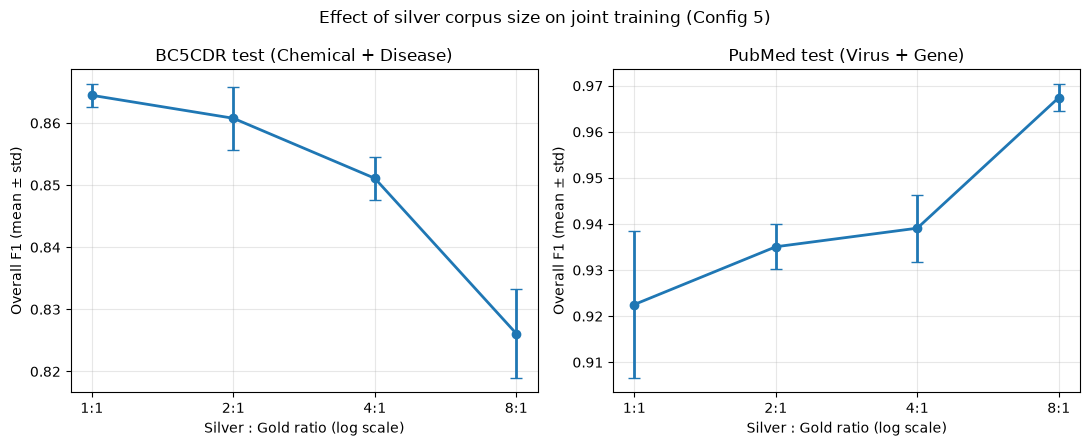

In [7]:
import json
import matplotlib.pyplot as plt

POINTS = [
    ('sweep_silver_1_1', 1),
    ('sweep_silver_2_1', 2),
    ('sweep_silver_4_1', 4),
    ('config_5_joint_uniform', 8),
]

def _load_overall_f1(name: str, test_set: str):
    fp = Path('outputs/results') / name / 'aggregated_results.json'
    if not fp.exists():
        return None
    data = json.loads(fp.read_text(encoding='utf-8'))
    block = data.get('test_sets', {}).get(test_set)
    if not block:
        return None
    f1 = block['overall']['f1']
    return float(f1['mean']), float(f1['std'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
for ax, test_set, title in zip(
    axes,
    ['test_bc5cdr', 'test_pubmed'],
    ['BC5CDR test (Chemical + Disease)', 'PubMed test (Virus + Gene)'],
):
    xs, means, stds = [], [], []
    for name, ratio in POINTS:
        stat = _load_overall_f1(name, test_set)
        if stat is None:
            continue
        xs.append(ratio)
        means.append(stat[0])
        stds.append(stat[1])
    if not xs:
        ax.set_title(f'{title}\n(no data yet)')
        continue
    ax.errorbar(xs, means, yerr=stds, marker='o', capsize=4, linewidth=2)
    ax.set_xscale('log', base=2)
    ax.set_xticks([1, 2, 4, 8])
    ax.set_xticklabels(['1:1', '2:1', '4:1', '8:1'])
    ax.set_xlabel('Silver : Gold ratio (log scale)')
    ax.set_ylabel('Overall F1 (mean ± std)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
fig.suptitle('Effect of silver corpus size on joint training (Config 5)')
fig.tight_layout()
plt.show()

## 10. Comparison table — Overall F1 across the four ratios

Compact summary suitable for pasting into a paper or report. Reads the
aggregated JSON files directly so the numbers are always in sync with
the latest run.

In [8]:
rows = []
for name, ratio in POINTS:
    fp = Path('outputs/results') / name / 'aggregated_results.json'
    if not fp.exists():
        rows.append((ratio, name, '—', '—'))
        continue
    data = json.loads(fp.read_text(encoding='utf-8'))
    summary = {}
    for test_set, label in [('test_bc5cdr', 'BC5CDR'), ('test_pubmed', 'PubMed')]:
        block = data.get('test_sets', {}).get(test_set)
        if not block:
            summary[label] = '—'
            continue
        f1 = block['overall']['f1']
        summary[label] = f"{f1['mean']:.3f} ± {f1['std']:.3f}"
    rows.append((ratio, name, summary.get('BC5CDR', '—'), summary.get('PubMed', '—')))

header = f"| Silver:Gold | Config | BC5CDR F1 | PubMed F1 |"
sep = '|---|---|---|---|'
print(header)
print(sep)
for ratio, name, bc5cdr_f1, pubmed_f1 in rows:
    print(f"| {ratio}:1 | {name} | {bc5cdr_f1} | {pubmed_f1} |")

| Silver:Gold | Config | BC5CDR F1 | PubMed F1 |
|---|---|---|---|
| 1:1 | sweep_silver_1_1 | 0.864 ± 0.002 | 0.923 ± 0.016 |
| 2:1 | sweep_silver_2_1 | 0.861 ± 0.005 | 0.935 ± 0.005 |
| 4:1 | sweep_silver_4_1 | 0.851 ± 0.003 | 0.939 ± 0.007 |
| 8:1 | config_5_joint_uniform | 0.826 ± 0.007 | 0.967 ± 0.003 |
